#1) Load data and tools

In [ ]:
!pip install -q transformers torch

In [ ]:
import pandas as pd
from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
from transformers import TrainingArguments, Trainer
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/IMDB Dataset.csv')
df.head(10)

#2) Data prepocessing

In [ ]:
df = df.drop_duplicates(subset="review").reset_index(drop=True)
df.shape

(49582, 2)

In [ ]:
df["review"]=df['review'].apply(lambda x: BeautifulSoup(x, "html.parser").get_text())
df['sentiment']=df['sentiment'].map({'positive':1,'negative':0})

In [ ]:
train_df, temp_df = train_test_split(df,test_size=0.2,random_state=42,stratify=df["sentiment"])
val_df, test_df = train_test_split(temp_df,test_size=0.5,random_state=42,stratify=temp_df["sentiment"])

#3) Model

In [ ]:
model_name = "bert-base-uncased"
#Geting the tokenizer
tokenizer=AutoTokenizer.from_pretrained(model_name)
#Downloading the model
model = AutoModelForSequenceClassification.from_pretrained(model_name,num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# changing to dataset for model
train_dataset = Dataset.from_pandas(train_df[["review", "sentiment"]],preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["review", "sentiment"]],preserve_index=False)
test_dataset = Dataset.from_pandas(test_df[["review", "sentiment"]],preserve_index=False)

#4) Tokenization

In [ ]:
def tokenize_function(batch):
  return tokenizer(batch["review"],truncation=True,padding="max_length",max_length=256)

In [ ]:
# Appling the tokenizer on datasets
train_dataset = train_dataset.map(tokenize_function,batched=True)
val_dataset = val_dataset.map(tokenize_function,batched=True)
test_dataset = test_dataset.map(tokenize_function,batched=True)

Map:   0%|          | 0/39665 [00:00<?, ? examples/s]

Map:   0%|          | 0/4958 [00:00<?, ? examples/s]

Map:   0%|          | 0/4959 [00:00<?, ? examples/s]

In [ ]:
train_dataset = train_dataset.rename_column("sentiment", "labels")
val_dataset = val_dataset.rename_column("sentiment", "labels")
test_dataset = test_dataset.rename_column("sentiment", "labels")
# No need for reviews anymore
train_dataset = train_dataset.remove_columns(["review"])
val_dataset = val_dataset.remove_columns(["review"])
test_dataset = test_dataset.remove_columns(["review"])

#5) Fine-Tuning

In [ ]:
# Model Arguments
training_args = TrainingArguments(
    output_dir="./bert-imdb",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    report_to="none"
)

In [ ]:
trainer = Trainer(model=model,args=training_args,train_dataset=train_dataset,eval_dataset=val_dataset)
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.242797,0.229255
2,0.143338,0.273124


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=4960, training_loss=0.19682147051057508, metrics={'train_runtime': 4207.9577, 'train_samples_per_second': 18.852, 'train_steps_per_second': 1.179, 'total_flos': 1.04363000108544e+16, 'train_loss': 0.19682147051057508, 'epoch': 2.0})

#6) Evaluation

In [ ]:
test_results = trainer.evaluate(test_dataset)
predictions = trainer.predict(test_dataset)

In [ ]:
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(y_pred[:20])
print(y_true[:20])

[1 1 0 1 0 0 0 1 0 0 1 1 1 1 0 1 0 1 0 1]
[1 1 0 1 0 1 0 1 0 0 1 1 1 1 0 1 1 1 1 1]


In [ ]:
print(classification_report(y_true,y_pred,target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.92      0.92      0.92      2470
    Positive       0.92      0.92      0.92      2489

    accuracy                           0.92      4959
   macro avg       0.92      0.92      0.92      4959
weighted avg       0.92      0.92      0.92      4959



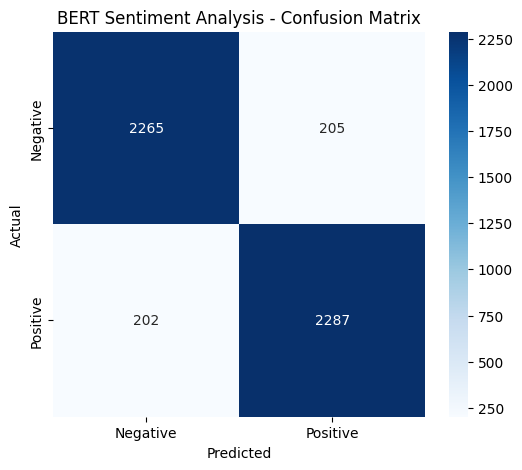

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT Sentiment Analysis - Confusion Matrix")
plt.show()